In [1]:
import sys

print(sys.executable)

C:\Users\shrid\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"]=(12,6)

In [26]:
fund_master = pd.read_csv(
    "data/processed/clean_fund_master.csv"
)

nav = pd.read_csv(
    "data/processed/clean_nav.csv"
)

aum = pd.read_csv(
    "data/processed/clean_aum.csv"
)

sip = pd.read_csv(
    "data/processed/clean_sip_inflows.csv"
)

category = pd.read_csv(
    "data/processed/clean_category_inflows.csv"
)

transactions = pd.read_csv(
    "data/processed/clean_transactions.csv"
)

folio = pd.read_csv(
    "data/processed/clean_folio_count.csv"
)

portfolio = pd.read_csv(
    "data/processed/clean_portfolio_holdings.csv"
)

performance = pd.read_csv(
    "data/processed/clean_performance.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(
    sip["month"]
)

folio["month"] = pd.to_datetime(
    folio["month"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

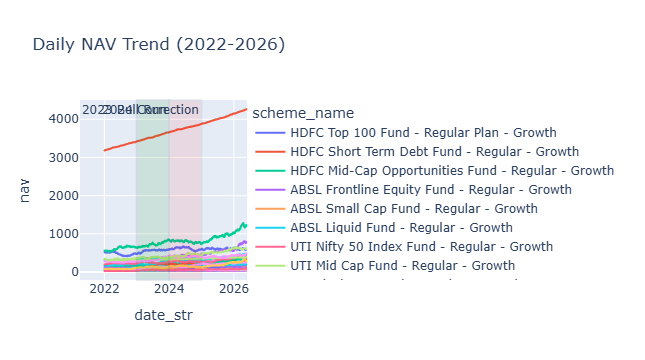

In [30]:
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

nav_plot["date_str"] = nav_plot["date"].dt.strftime("%Y-%m-%d")

fig = px.line(
    nav_plot,
    x="date_str",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    annotation_text="2024 Correction"
)

fig.show()

fig.write_image(
    "reports/charts/nav_trend.png"
)

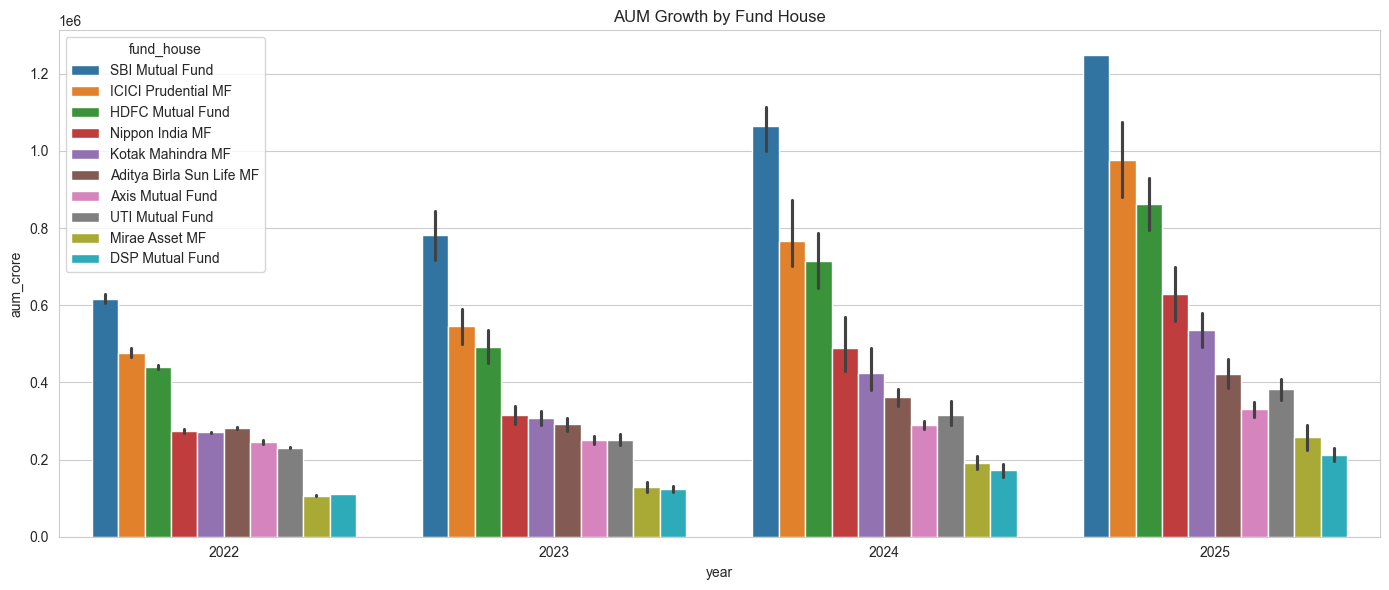

In [31]:
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.savefig(
    "reports/charts/aum_growth.png"
)

plt.show()

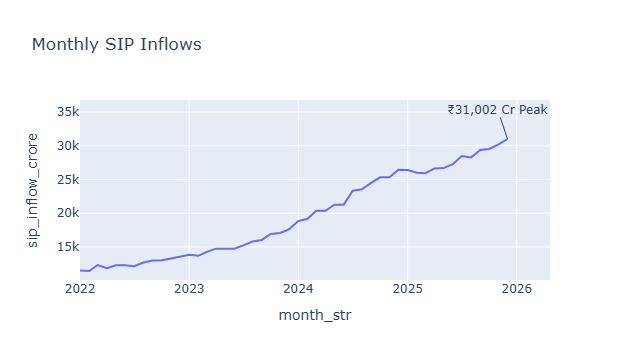

In [32]:
sip["month_str"] = sip["month"].dt.strftime("%Y-%m")

fig = px.line(
    sip,
    x="month_str",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month_str"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr Peak",
    showarrow=True
)

fig.show()

fig.write_image(
    "reports/charts/sip_trend.png"
)

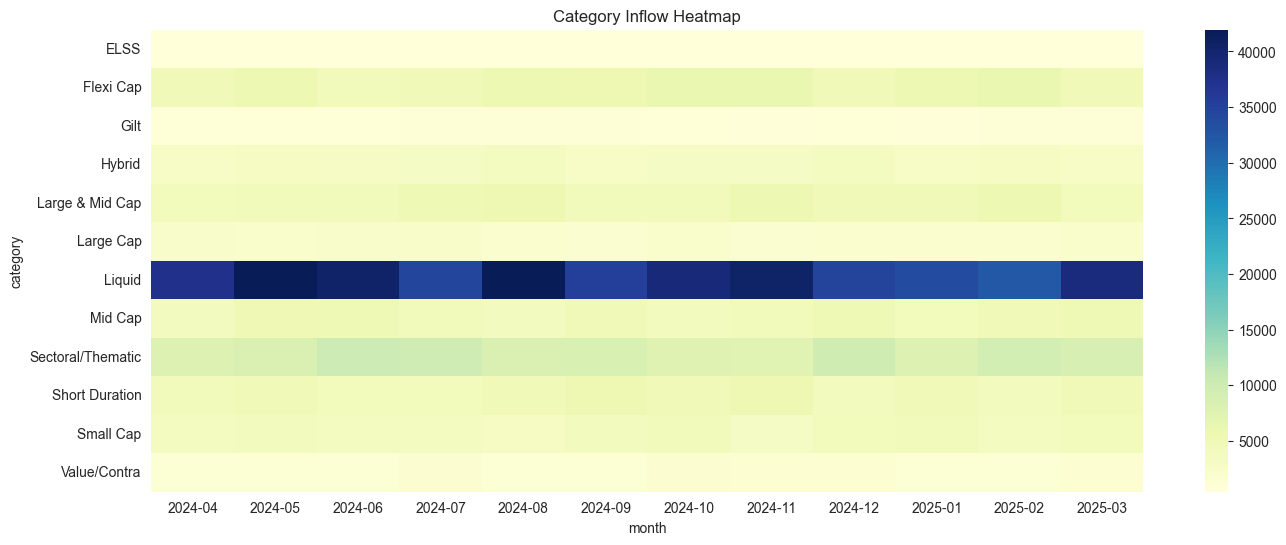

In [33]:
heat = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    heat,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "reports/charts/category_heatmap.png"
)

plt.show()

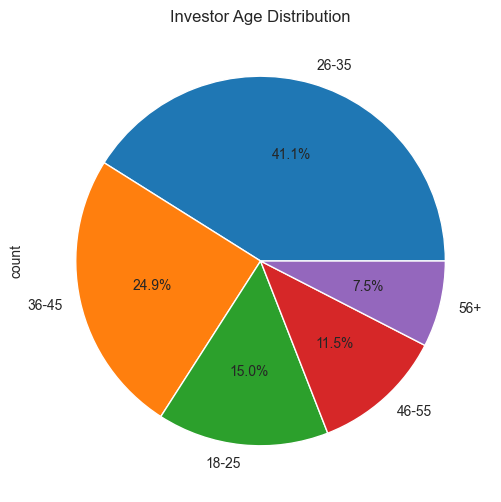

In [34]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.savefig(
    "reports/charts/age_distribution.png"
)

plt.show()

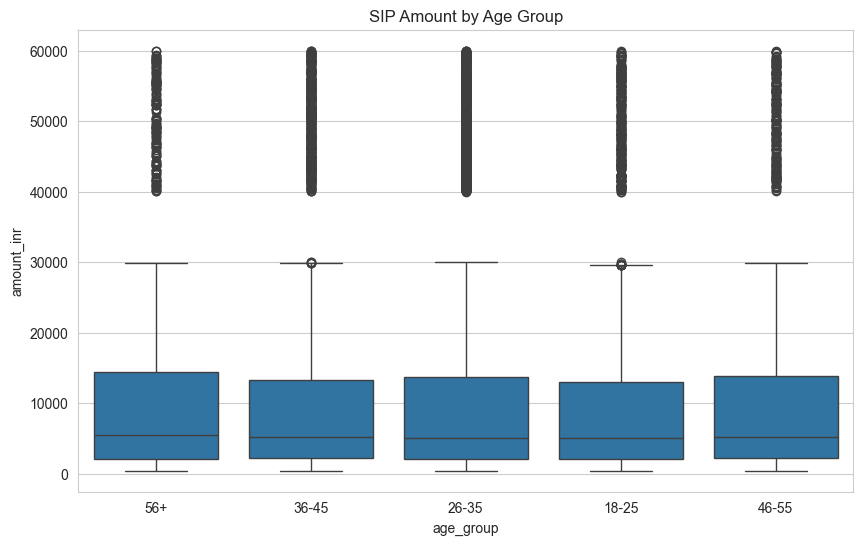

In [35]:
sip_tx = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_tx,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.savefig(
    "reports/charts/sip_boxplot_age.png"
)

plt.show()

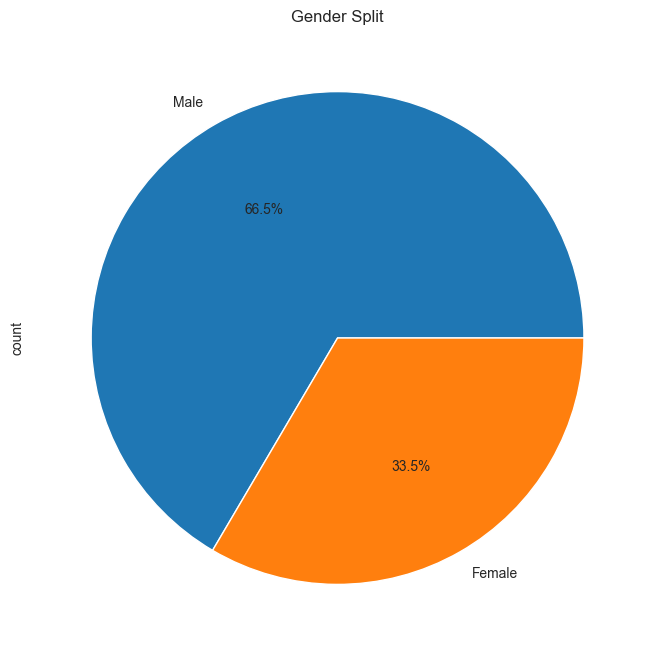

In [45]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Split")

plt.savefig(
    "reports/charts/gender_split.png"
)

plt.show()

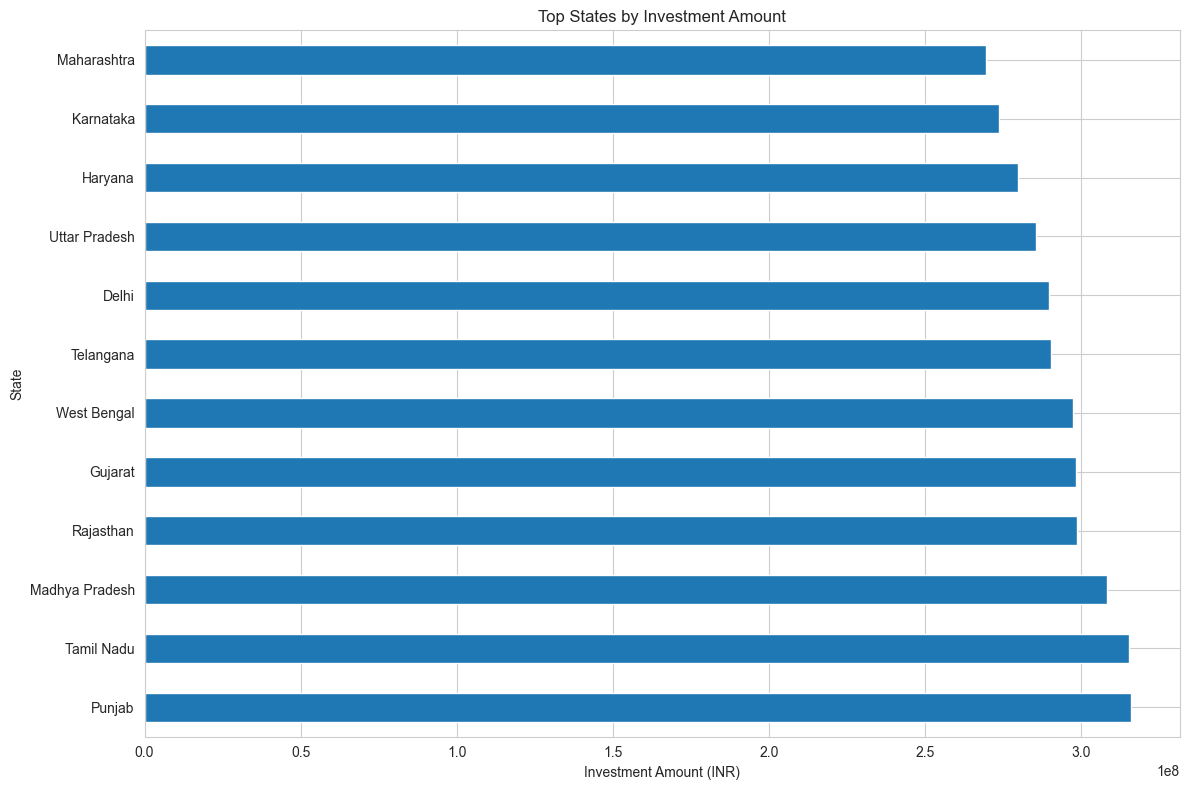

In [36]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_data.head(15).plot(
    kind="barh"
)

plt.title("Top States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "reports/charts/state_sip_distribution.png"
)

plt.show()

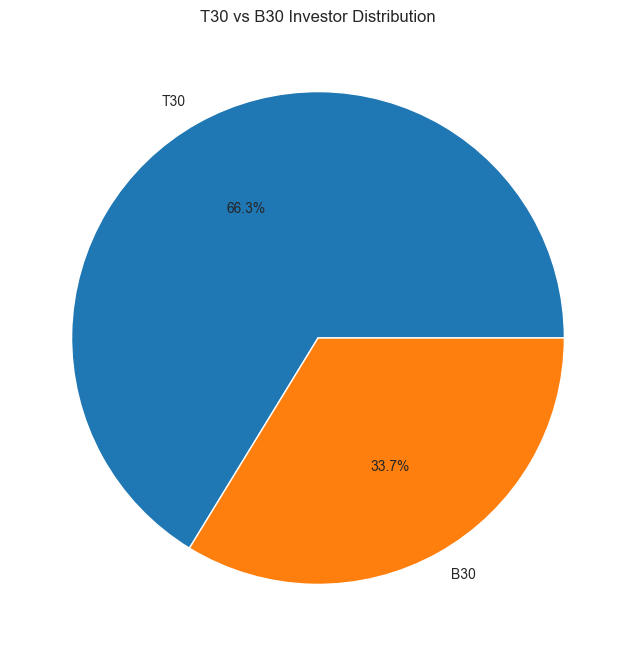

In [37]:
city_tier = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "reports/charts/t30_b30_distribution.png"
)

plt.show()

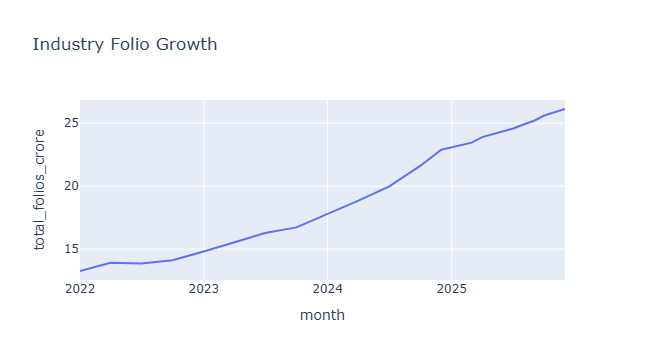

In [38]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Growth"
)

fig.show()

fig.write_image(
    "reports/charts/folio_growth.png"
)

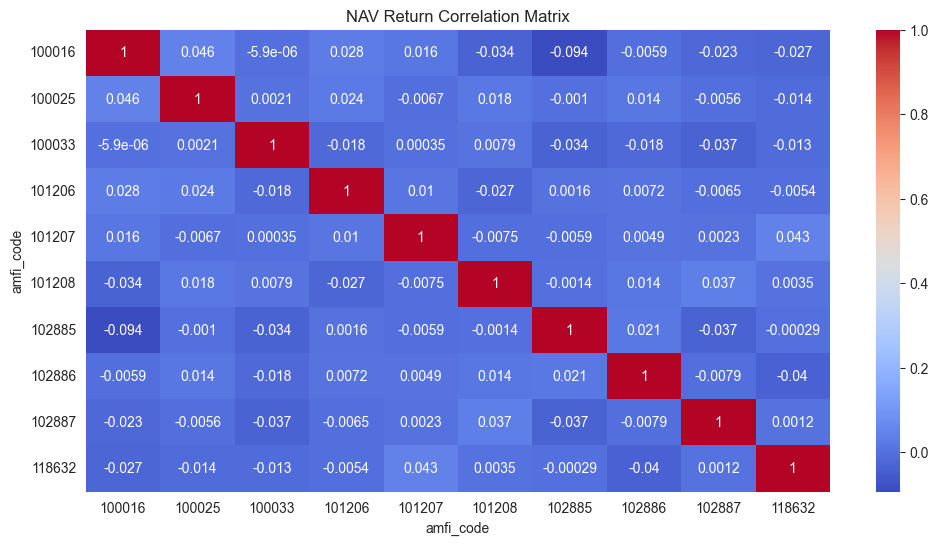

In [44]:
funds = nav["amfi_code"].unique()[:10]

corr_df = nav[
    nav["amfi_code"].isin(funds)
]

pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "reports/charts/nav_correlation.png"
)

plt.show()

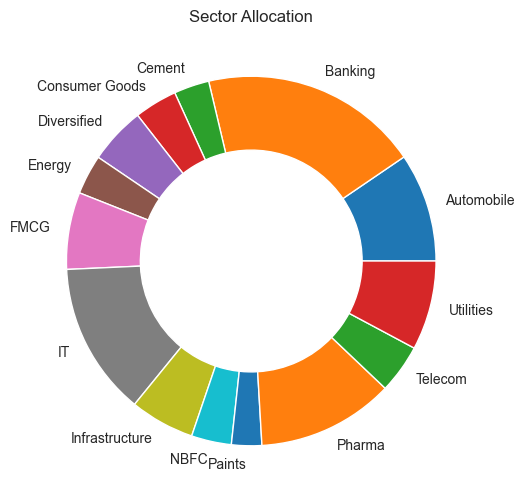

In [40]:
sector = (
    portfolio
    .groupby("sector")
    ["weight_pct"]
    .sum()
)

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.savefig(
    "reports/charts/sector_allocation.png"
)

plt.show()

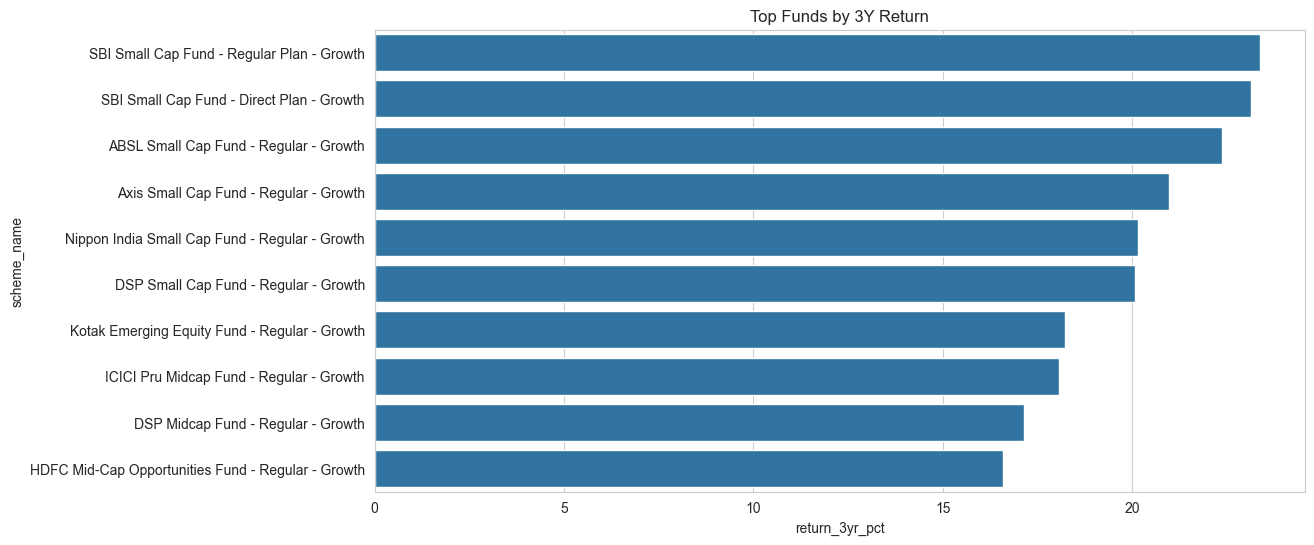

In [41]:
top = performance.nlargest(
    10,
    "return_3yr_pct"
)

sns.barplot(
    data=top,
    x="return_3yr_pct",
    y="scheme_name"
)

plt.title("Top Funds by 3Y Return")

plt.savefig(
    "reports/charts/top_funds_return.png"
)

plt.show()

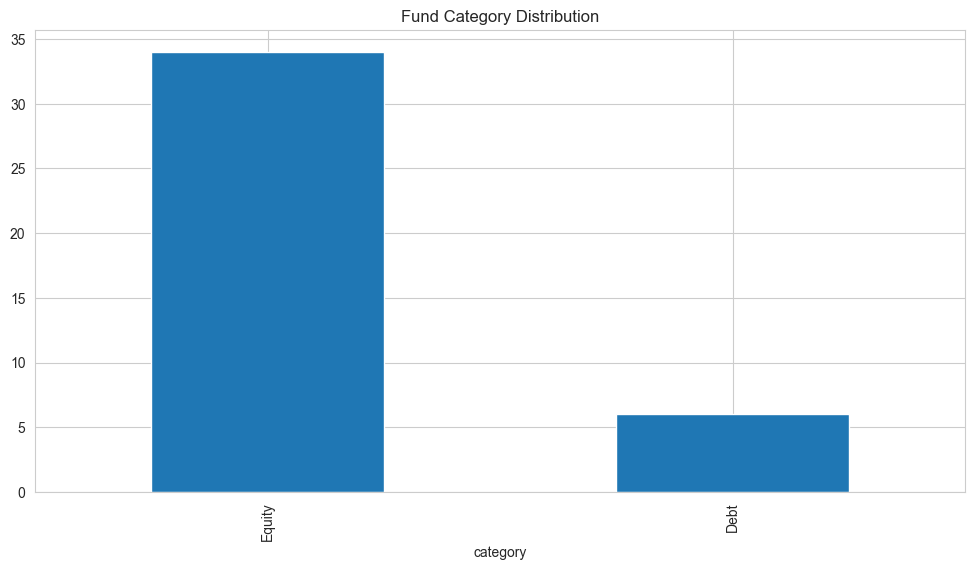

In [42]:
fund_master["category"].value_counts().plot(
    kind="bar"
)

plt.title("Fund Category Distribution")

plt.savefig(
    "reports/charts/category_distribution.png"
)

plt.show()

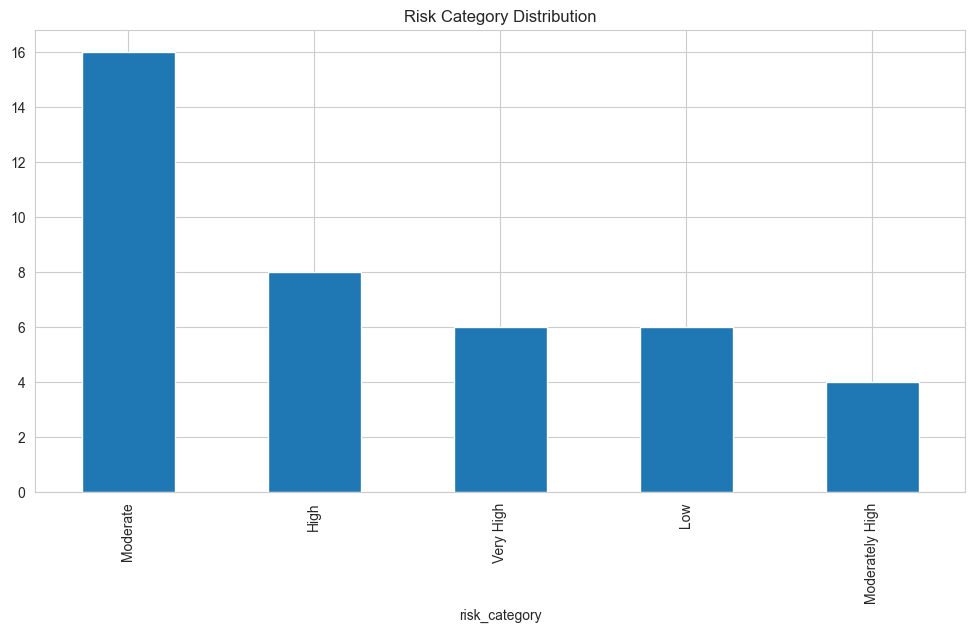

In [43]:
fund_master["risk_category"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Category Distribution")

plt.savefig(
    "reports/charts/risk_distribution.png"
)

plt.show()

1. Strong Growth in SIP Investments

Monthly SIP inflows increased steadily from 2022 to 2025, reaching an all-time high of ₹31,002 Cr in December 2025 (Chart: SIP Inflow Trend).

2. SBI Mutual Fund Leads Industry AUM

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses, highlighting its dominant market position (Chart: AUM Growth by AMC).

3. Equity Funds Dominate Fund Universe

The majority of schemes belong to Equity categories, indicating strong investor preference for equity-oriented investments (Chart: Fund Category Distribution).

4. Folio Count Nearly Doubled

Industry folio count increased significantly from 13.26 Cr in Jan 2022 to over 26 Cr by Dec 2025, showing rapid retail participation growth (Chart: Folio Growth Trend).

5. Large Cap and Flexi Cap Categories Attracted Maximum Inflows

Large Cap and Flexi Cap funds consistently recorded strong positive inflows across multiple months (Chart: Category Inflow Heatmap).

6. Most Investors Fall in Middle Age Groups

The largest share of investors belongs to the 25–45 age bracket, indicating that working professionals drive mutual fund investments (Chart: Age Group Distribution).

7. Tier-1 Cities Contribute Majority of Investments

T30 cities account for a major portion of investment activity compared to B30 cities (Chart: T30 vs B30 Distribution).

8. SIP Investments Show Significant Variation Across Age Groups

Boxplot analysis indicates higher investment variability among middle-aged investors compared to younger investors (Chart: SIP Amount by Age Group).

9. Mutual Fund Returns Show Positive Correlation

Most selected funds exhibit strong positive return correlations, suggesting similar reactions to overall market movements (Chart: NAV Correlation Matrix).

10. Financial Services and Banking Dominate Portfolio Allocation

Portfolio analysis shows that Banking and Financial Services sectors receive the highest allocation across equity mutual funds (Chart: Sector Allocation Donut).